# 🧪 NGCM Stream Sediment — Heavy Anomaly Detection Preprocessing Pipeline

**Dataset:** `NGCM-Stream-Sediment-Analysis-Updated.xlsx`  
**Target Features:** `As_ppm` (Arsenic), `Pb_ppm` (Lead), `Hg_ppb` (Mercury)  
**Coordinates:** `X` (Longitude), `Y` (Latitude)  
**Models to Feed:** One-Class SVM · Isolation Forest

---
## Pipeline Overview

| Step | Action | Why |
|------|--------|-----|
| 1 | Data Isolation & Cleaning | Extract target features; handle NaNs |
| 2 | Log Transformation | Correct right-skew of geochemical data |
| 3 | Robust Scaling | Equalise feature magnitudes; outlier-resistant |
| 4 | Coordinate Separation | Keep coords out of training; re-attach for mapping |

## 0 · Imports & Setup

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')

All libraries loaded successfully.
   NumPy  1.26.4
   Pandas 2.1.4


---
## Step 1 · Data Isolation & Cleaning

We extract only the **three chemical features** and the **two coordinate columns**.  
Coordinates are **immediately separated** so they are never seen by the models.

In [23]:
#  Load raw data 
RAW_PATH = '../Heavy-Metal-Anomaly-Detection/data/NGCM-Stream-Sediment-Analysis-Updated.xlsx'

df_raw = pd.read_excel(RAW_PATH)
print(f'Raw dataset : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

df_raw.sample(6)

Raw dataset : 10,004 rows × 73 columns


(10004, 73)

In [24]:
df_raw.sample(10)

,FID,Shape *,gid,objectid,sampleno,X,Y,Si02_%,Al2O3_%,Fe2O3_%,...,Ta_ppm,W_ppm,U_ppm,Pt_ppb,Pd_ppb,In_ppm,F_ppm,Te_ppm,Tl_ppm,toposheet
7991,7991,Point,109393,109393,57A11/010/S/14,76.6769,15.2590,49.4800,13.3600,9.9200,...,0.8630,0.0000,1.7018,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57A11
3301,3301,Point,5297,5297,57F03/139/SS/00,77.2315,14.4212,63.4300,16.2500,4.0200,...,1.0610,2.5000,5.0430,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57F03
4937,4937,Point,77271,77271,57B05/118/SS/12,76.3522,14.9036,64.7881,16.8400,3.1700,...,0.7309,2.5000,2.5340,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57B05
2088,2088,Point,3830,3830,57F07/079/SS/12,77.4083,14.3491,62.8600,16.7100,5.1100,...,1.8810,2.5000,6.7210,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57F07
4349,4349,Point,74107,74107,57B3/145/SS/12,76.0835,14.4398,62.3700,16.0200,5.7900,...,1.1994,2.5000,2.1722,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57B03
2900,2900,Point,4848,4848,57F/5-CS-24/10-12,77.4269,14.7772,58.6330,16.6100,5.7800,...,0.9040,2.5000,3.2450,0.6000,0.0000,0.0000,0.0000,0.0000,0.0000,57F05
5896,5896,Point,87267,87267,57B11/097/S/2012,76.7317,14.3678,62.7200,17.4300,3.9700,...,2.1607,0.0000,2.9212,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57B11
6721,6721,Point,92604,92604,57A03/118/S/14,76.1025,15.4036,64.5000,11.2500,2.0600,...,0.1000,0.0000,1.0491,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57A03
5059,5059,Point,77637,77637,57B1/039/SS/2011-12,76.1942,14.7947,61.9400,11.9600,5.3100,...,0.8540,5.0000,1.6620,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57B01
9287,9287,Point,203256,203256,57G01/044/S/15,77.0277,13.8133,63.9630,16.1750,3.8800,...,0.8004,0.8032,4.7369,0.0000,0.0000,0.0941,175.0000,0.0977,2.0082,57G01


In [11]:
# Define columns of interest 
CHEM_FEATURES  = ['As_ppm', 'Pb_ppm', 'Hg_ppb']
COORD_FEATURES = ['X', 'Y']          # X = Longitude, Y = Latitude
ALL_COLS       = COORD_FEATURES + CHEM_FEATURES

df_selected = df_raw[ALL_COLS].copy()
print('Selected columns:', ALL_COLS)
df_selected.head()

Selected columns: ['X', 'Y', 'As_ppm', 'Pb_ppm', 'Hg_ppb']


,X,Y,As_ppm,Pb_ppm,Hg_ppb
0,77.1944,15.5991,4.9800,32.1000,6.0000
1,77.2130,15.5991,5.4300,26.8000,6.0000
2,77.2315,15.5991,4.4600,27.3000,5.0000
3,77.2500,15.5991,5.0800,29.2000,9.0000
4,77.0093,15.6171,5.7400,22.7000,7.0000


In [21]:
# Missing-value audit 
null_counts = df_selected.isnull().sum()
null_pct    = (null_counts / len(df_selected) * 100).round(2)

audit = pd.DataFrame({'Missing Count': null_counts, 'Missing %': null_pct})
print(' Missing Value Audit ')
print(audit)
print(f'\nTotal rows before cleaning: {len(df_selected):,}')

 Missing Value Audit 
        Missing Count  Missing %
X                   0     0.0000
Y                   0     0.0000
As_ppm              0     0.0000
Pb_ppm              0     0.0000
Hg_ppb              0     0.0000

Total rows before cleaning: 10,004


In [14]:
# Handle missing values 

MISSING_THRESHOLD = 5.0   # % — switch to imputation above this threshold

chem_null_max = null_pct[CHEM_FEATURES].max()

if chem_null_max == 0:
    df_clean = df_selected.copy()
    print(f' No missing values detected — no imputation needed.')

elif chem_null_max <= MISSING_THRESHOLD:
    df_clean = df_selected.dropna(subset=CHEM_FEATURES).copy()
    dropped = len(df_selected) - len(df_clean)
    print(f' Dropped {dropped} rows with NaN in chemical columns.')

else:
    imputer = SimpleImputer(strategy='median')
    df_clean = df_selected.copy()
    df_clean[CHEM_FEATURES] = imputer.fit_transform(df_selected[CHEM_FEATURES])
    print(f' Median imputation applied (max NaN% = {chem_null_max:.1f}%).')



 No missing values detected — no imputation needed.

Rows after cleaning : 10,004


In [25]:
# Descriptive statistics of raw chemistry 
print('Raw Chemistry Statistics')
df_clean[CHEM_FEATURES].describe().T.assign(
    skewness=df_clean[CHEM_FEATURES].skew()
)

Raw Chemistry Statistics


,count,mean,std,min,25%,50%,75%,max,skewness
As_ppm,10004.0000,3.0614,6.3975,0.0000,0.0000,1.4728,3.4400,150.0000,6.4237
Pb_ppm,10004.0000,17.1910,11.2616,0.0000,12.8000,16.7000,20.5000,482.9000,18.6864
Hg_ppb,10004.0000,5.5212,10.4861,0.0000,0.0000,5.0000,8.0000,570.0000,21.6099


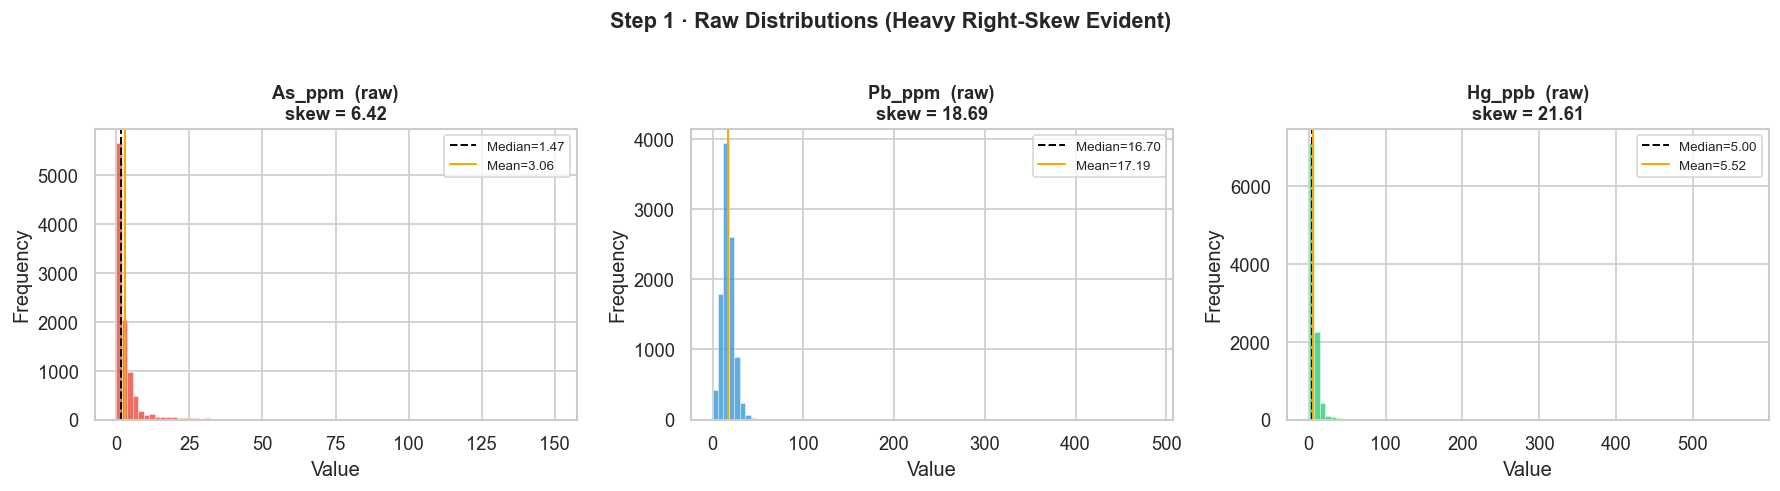

Saved → step1_raw_distributions.png


In [26]:
# Visualise raw distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#E74C3C', '#3498DB', '#2ECC71']

for ax, col, color in zip(axes, CHEM_FEATURES, colors):
    data = df_clean[col]
    ax.hist(data, bins=80, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_title(f'{col}  (raw)\nskew = {data.skew():.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.2, label=f'Median={data.median():.2f}')
    ax.axvline(data.mean(),   color='orange', linestyle='-',  linewidth=1.2, label=f'Mean={data.mean():.2f}')
    ax.legend(fontsize=8)

fig.suptitle('Step 1 · Raw Distributions (Heavy Right-Skew Evident)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step1_raw_distributions.png', bbox_inches='tight')
plt.show()
print('Saved → step1_raw_distributions.png')

---
## Step 2 · Log Transformation  (`numpy.log1p`)

Geochemical concentrations follow a **log-normal distribution**: most samples are near-zero, but a few spikes reach extreme values.  
Without transformation the anomaly detector treats *normal geological variation* (high values) as outliers.

> **`log1p(x)` = log(1 + x)`** — safe for zero values (avoids `log(0) = -∞`).

In [27]:
# Applying log1p to chemical features only
df_log = df_clean.copy()
df_log[CHEM_FEATURES] = np.log1p(df_clean[CHEM_FEATURES])

print('Post-Log Statistics')
df_log[CHEM_FEATURES].describe().T.assign(
    skewness=df_log[CHEM_FEATURES].skew()
)

Post-Log Statistics


,count,mean,std,min,25%,50%,75%,max,skewness
As_ppm,10004.0000,0.8865,0.9145,0.0000,0.0000,0.9054,1.4907,5.0173,0.7862
Pb_ppm,10004.0000,2.7992,0.4866,0.0000,2.6247,2.8736,3.0681,6.1819,-1.7290
Hg_ppb,10004.0000,1.2977,1.1144,0.0000,0.0000,1.7918,2.1972,6.3474,0.0143


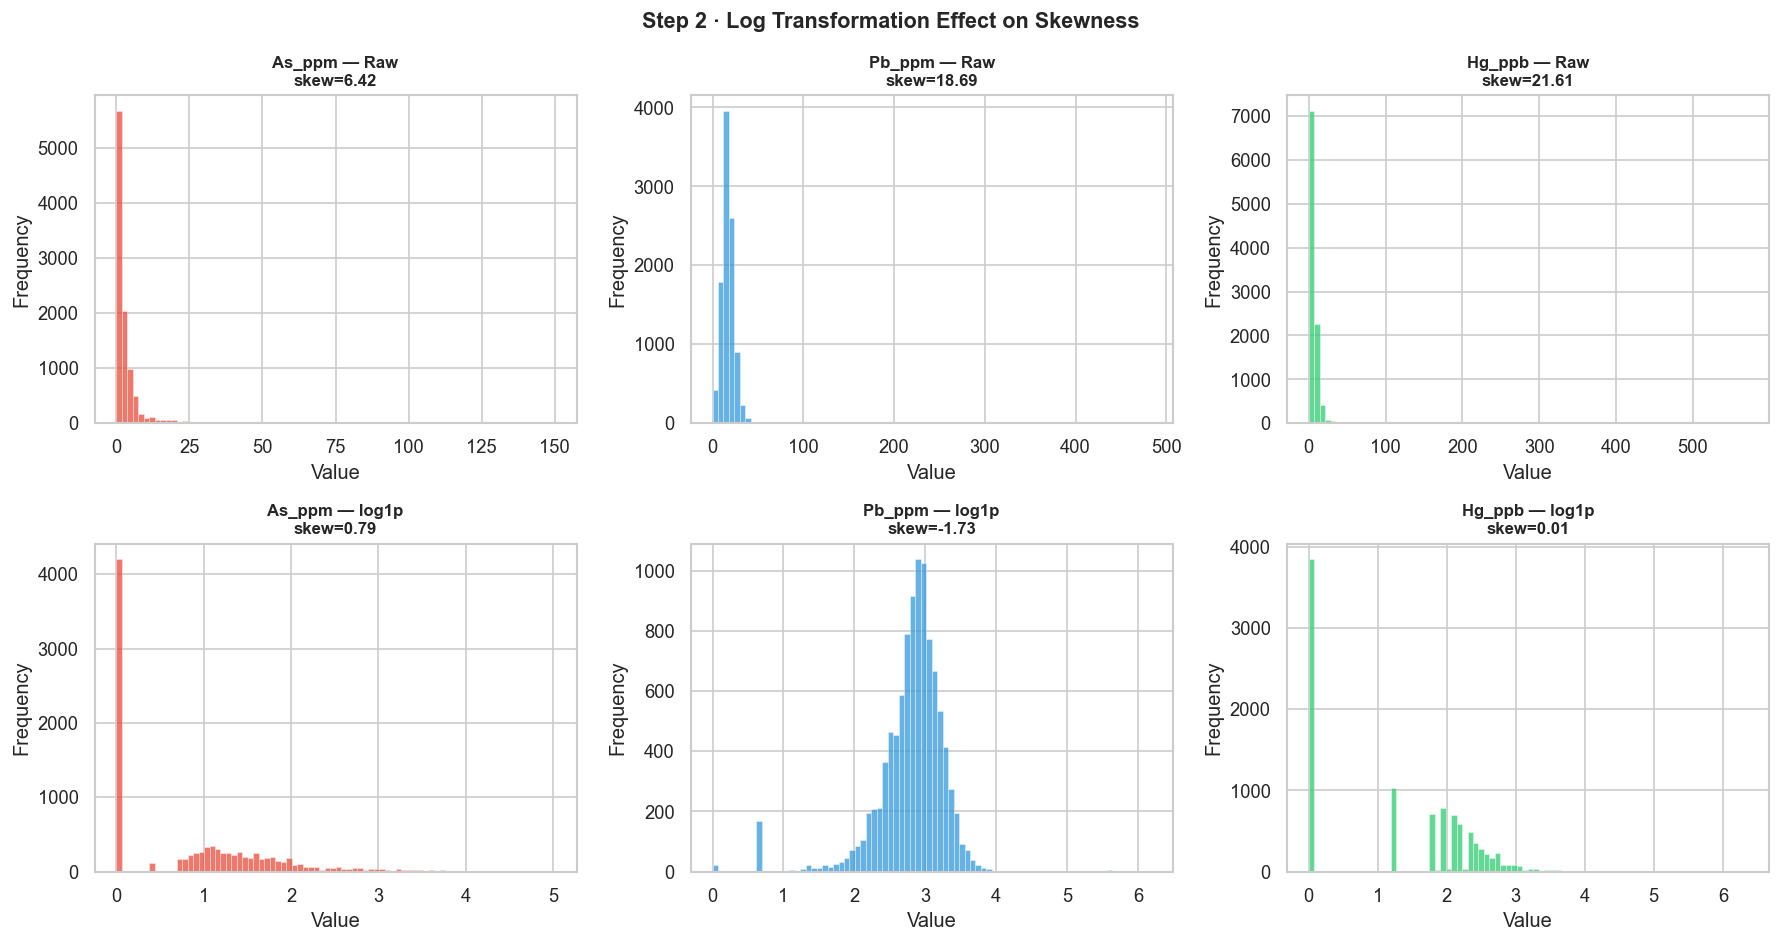

Saved → step2_log_transformation.png


In [28]:
# Before/After comparison plot 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = ['#E74C3C', '#3498DB', '#2ECC71']
labels = ['Before (Raw)', 'After (log1p)']

for col_idx, (col, color) in enumerate(zip(CHEM_FEATURES, colors)):
    for row_idx, (data, label) in enumerate([
        (df_clean[col], 'Raw'),
        (df_log[col],   'log1p')
    ]):
        ax = axes[row_idx, col_idx]
        ax.hist(data, bins=80, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
        ax.set_title(f'{col} — {label}\nskew={data.skew():.2f}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')

fig.suptitle('Step 2 · Log Transformation Effect on Skewness', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('step2_log_transformation.png', bbox_inches='tight')
plt.show()
print('Saved → step2_log_transformation.png')

In [29]:
# Skewness improvement summary 
skew_before = df_clean[CHEM_FEATURES].skew().rename('Skew (Raw)')
skew_after  = df_log[CHEM_FEATURES].skew().rename('Skew (log1p)')
skew_df = pd.concat([skew_before, skew_after], axis=1)
skew_df['Reduction %'] = ((skew_before - skew_after) / skew_before.abs() * 100).round(1)
print('Skewness Reduction')
skew_df

Skewness Reduction


,Skew (Raw),Skew (log1p),Reduction %
As_ppm,6.4237,0.7862,87.8000
Pb_ppm,18.6864,-1.7290,109.3000
Hg_ppb,21.6099,0.0143,99.9000
